# Tiền xử lý dữ liệu chuỗi thời gian

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

df = pd.read_csv('../data/raw/VNDA.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['Date']) # Loại bỏ dòng lỗi nếu có
df = df.sort_values('Date')
df = df.set_index('Date')

series_original = df['Adjusted Close'].copy()

print(f"Dữ liệu từ: {df.index.min()} đến {df.index.max()}")
print(f"Tổng số dòng: {len(df)}")

Dữ liệu từ: 2006-04-12 00:00:00 đến 2022-12-12 00:00:00
Tổng số dòng: 4197


# 2.4.2 phân tích khám phá chuỗi thời gian.<br>
## a. vẽ time plot và xác định bằng mắt các thành phần: xu hướng, mùa vụ, nhiễu.

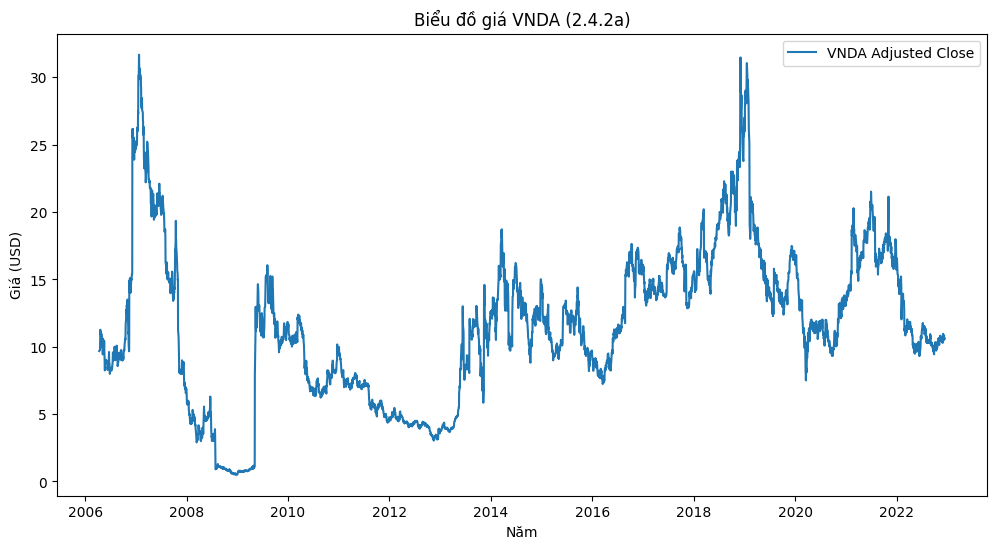

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(series_original, label='VNDA Adjusted Close')
plt.title('Biểu đồ giá VNDA (2.4.2a)')
plt.xlabel('Năm')
plt.ylabel('Giá (USD)')
plt.legend()
plt.show()

Đánh giá xu hướng(trend): giá cổ phiếu VNDA cao nhất vào khoảng năm 2007 và 2019, xuất hiện các đợt tăng giảm đột đột ngột.<br>
Đánh giá mùa vụ(seasonality): không có tính mùa vụ, các đỉnh không cách đều nhau theo từng chu kỳ.<br>
Đánh giá nhiễu(Noise): dữ liệu có độ nhiễu cao, dao động liên tục, là đặc trưng của dữ liệu tài chính vì có các dao động ngắn hạn và liên tục.<br>

## b. Vẽ AFCF và PACF với lag tối đa cụ thể.<br>

In [6]:
n = len(df)
lag_max = int(min(10 * np.log10(n), n / 5))
print(f"Số lượng quan sát (n): {n}")
print(f"Số lag tối đa nên chọn: {lag_max}")

Số lượng quan sát (n): 4197
Số lag tối đa nên chọn: 36


### Vẽ sơ đồ tương quan AFCF

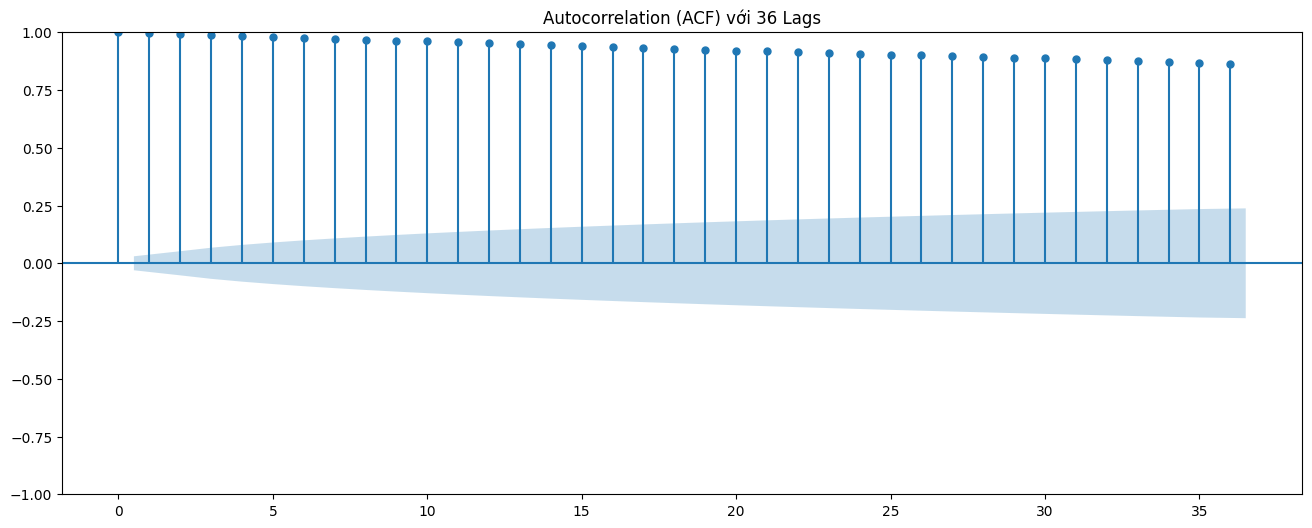

In [16]:
#Thiết lập số lag là 36
n_lags = 36
fig, ax = plt.subplots(1, 1, figsize=(16, 6))

# Vẽ ACF
plot_acf(df['Adjusted Close'], lags=n_lags, ax=ax)
ax.set_title(f'Autocorrelation (ACF) với {n_lags} Lags')


plt.show()

-Sơ đồ tương quan có các cột hệ số tương quan giảm chậm từ lag 1 tới lag 36, ở lag 36 tỉ lệ tương quan vẫn ở mức cao.<br>
-Tất cả 36 lag đều nằm ngoài vùng tin cậy(vùng bóng màu xanh mờ). <br>
-Dữ liệu có tính tương quan mạnh.

### Vẽ sơ đồ tương quan ACF

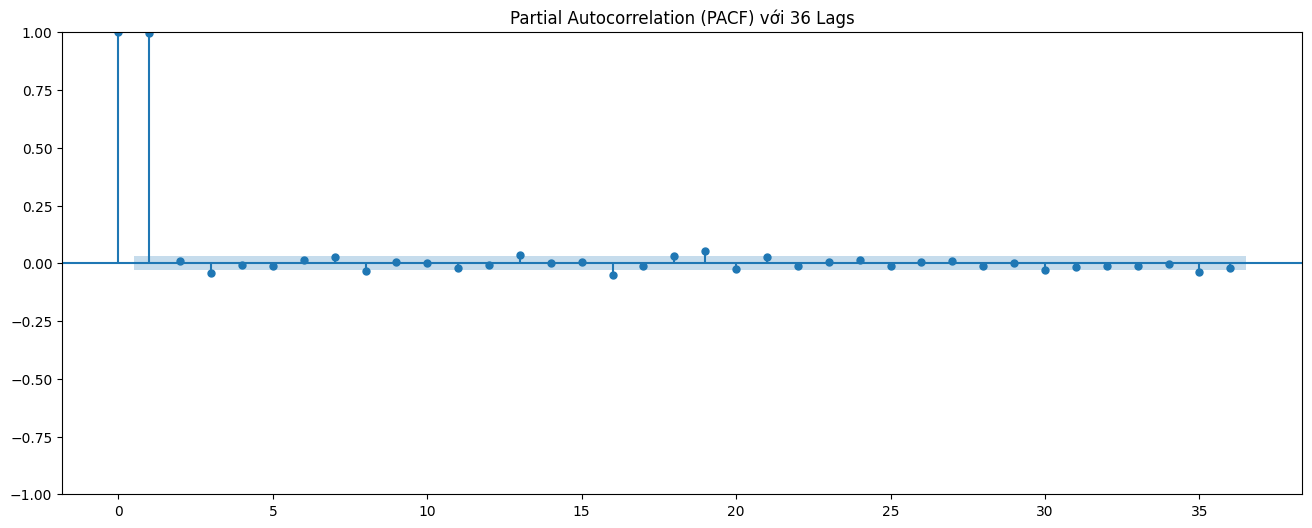

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(16, 6))
plot_pacf(df['Adjusted Close'], lags=n_lags, ax=ax)
ax.set_title(f'Partial Autocorrelation (PACF) với {n_lags} Lags')

plt.show()

-Giá trị lag 1 và lag 2 vượt cao khỏi vùng tin cậy, cho thấy sự tương quan mạnh với hai ngày trước đó.<br>
-Từ lag 3 các hệ số đa phần đi trong vùng tin cậy, có một vài cột vượt qua vùng tin cậy nhưng không đáng kể so với lag1 và lag 2.<br>


## c. Tính rolling statistics: trung bình trượt và độ lệch chuẩn với cửa số trượt 7, 30 và 90 ngày (hoặc tương đương). Có thể trực quan hóa và nhận xét tính dừng sơ bộ.

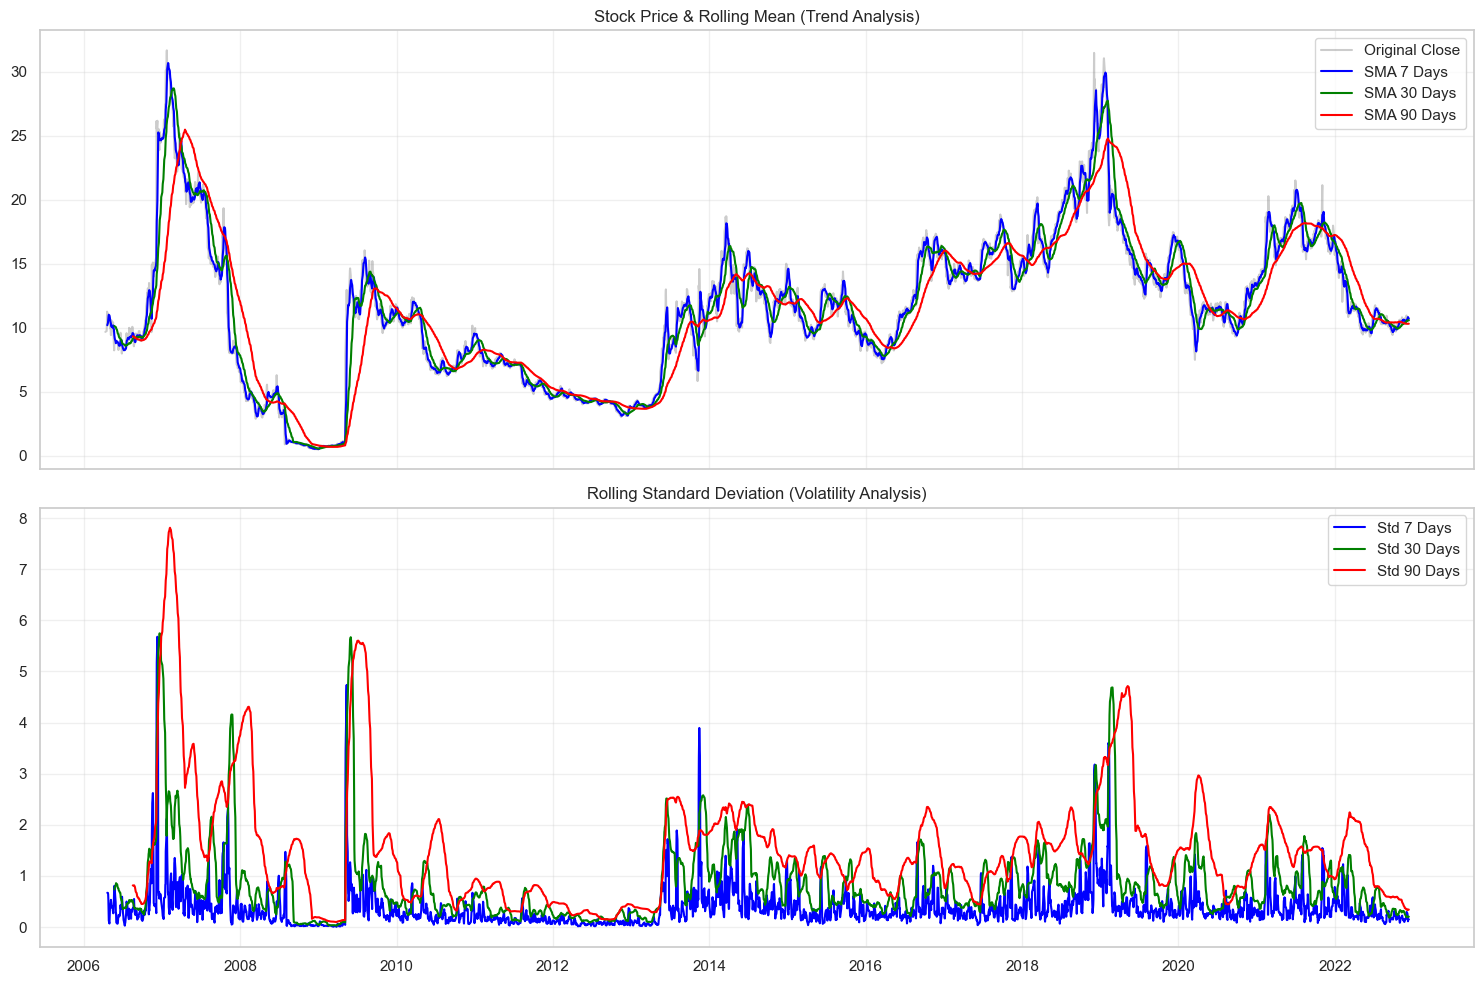

In [10]:

df = pd.read_csv('../data/raw/VNDA.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Sắp xếp theo thời gian (quan trọng để tính rolling chính xác)
df = df.sort_values('Date')

# Đặt Date làm Index
df.set_index('Date', inplace=True)

# 3. Tính toán Rolling Statistics cho cột 'Close'
# Bạn có thể thay 'Close' bằng 'Adjusted Close' nếu muốn
windows = [7, 30, 90]
for w in windows:
    df[f'SMA_{w}'] = df['Close'].rolling(window=w).mean()
    df[f'Std_{w}'] = df['Close'].rolling(window=w).std()

# 4. Trực quan hóa
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Đồ thị Trung bình trượt (SMA)
ax1.plot(df['Close'], label='Original Close', alpha=0.4, color='gray')
colors = {7: 'blue', 30: 'green', 90: 'red'}
for w in windows:
    ax1.plot(df[f'SMA_{w}'], label=f'SMA {w} Days', color=colors[w])
ax1.set_title('Stock Price & Rolling Mean (Trend Analysis)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Đồ thị Độ lệch chuẩn (Volatility)
for w in windows:
    ax2.plot(df[f'Std_{w}'], label=f'Std {w} Days', color=colors[w])
ax2.set_title('Rolling Standard Deviation (Volatility Analysis)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


--Nhận xét về tính dừng sơ bộ.<br>
- đồ thị trung bình trượt (SMA) có dốc độ lớn với mọi cửa sổ trượt, cho thấy dữ liệu có tính trend, không dừng.<br>
- đồ thị độ lệch chuẩn thay đổi biên độ theo thời gian, phương sai không là hằng số, không dừng.<br>

# 2.4.3 các kỹ thuật tiền xử lý nâng cao.<br>


## a. Xử lý khoảng trống và nội suy so sánh:

Index(['Low', 'Open', 'Volume', 'High', 'Close', 'Adjusted Close'], dtype='str')


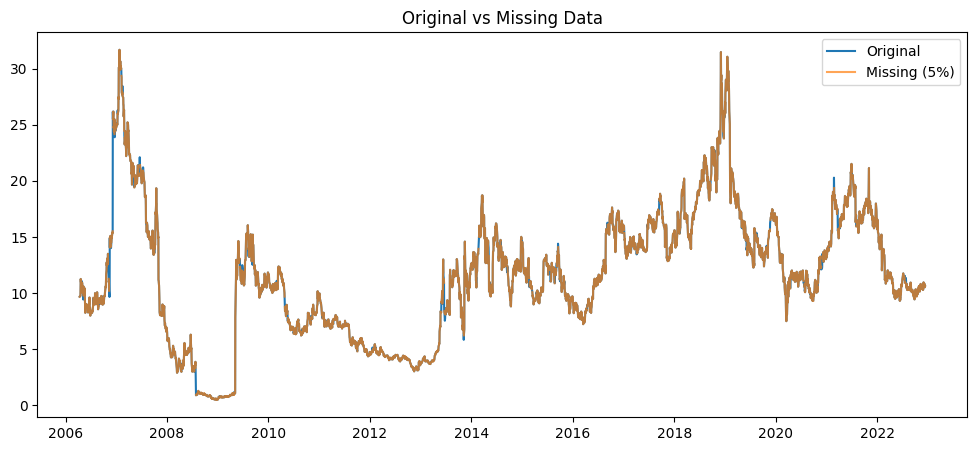

===== MAE & RMSE =====
Forward Fill: MAE = 0.3387, RMSE = 0.8644
Linear: MAE = 0.2501, RMSE = 0.5631
Polynomial (order=2): MAE = 0.3015, RMSE = 0.6931
Polynomial (order=3): MAE = 0.3041, RMSE = 0.6878
Spline (cubic): MAE = 0.8262, RMSE = 1.1695

===== Ljung-Box Test =====
Forward Fill: p-value = 0.3854
Linear: p-value = 0.0000
Polynomial (order=2): p-value = 0.0000
Polynomial (order=3): p-value = 0.0000
Spline (cubic): p-value = 0.0000


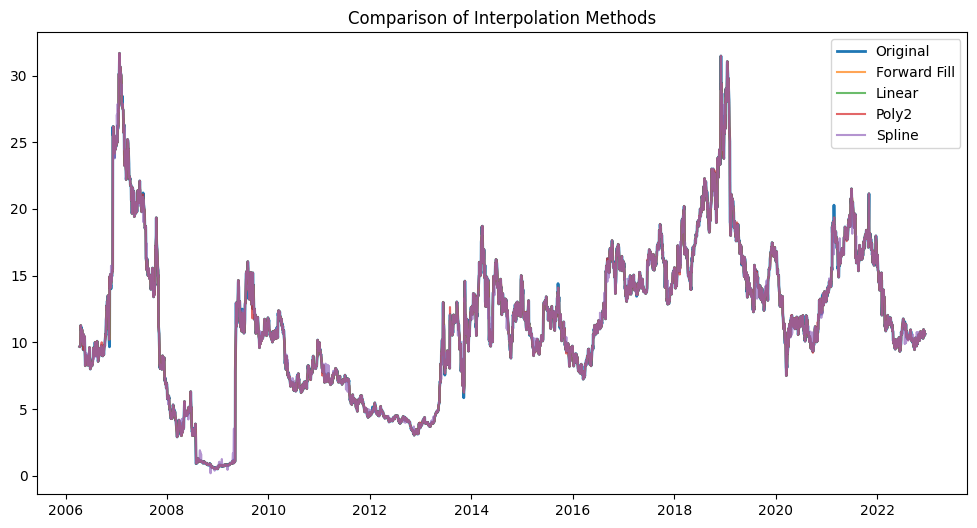

In [6]:
# =========================================
# 2.4.3.a Missing Data + Interpolation
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox

# =========================
# 1. Chuẩn bị dữ liệu
# =========================

df = pd.read_csv('../data/raw/VNDA.csv')

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)

df.head()
print(df.columns)

series = df['Adjusted Close']

# =========================
# 2. Tạo missing 5% (MCAR)
# =========================
np.random.seed(42)

mask = np.random.choice(len(series), int(0.05 * len(series)), replace=False)

series_missing = series.copy()
series_missing.iloc[mask] = np.nan

# Vẽ so sánh
plt.figure(figsize=(12,5))
plt.plot(series, label='Original')
plt.plot(series_missing, label='Missing (5%)', alpha=0.7)
plt.legend()
plt.title("Original vs Missing Data")
plt.show()

# =========================
# 3. Nội suy các phương pháp
# =========================

# Forward fill
ffill = series_missing.ffill()

# Linear interpolation
linear = series_missing.interpolate(method='linear')

# Polynomial (bậc 2 và 3)
poly2 = series_missing.interpolate(method='polynomial', order=2)
poly3 = series_missing.interpolate(method='polynomial', order=3)

# Spline (cubic)
spline = series_missing.interpolate(method='spline', order=3)

# =========================
# 4. Đánh giá MAE & RMSE
# =========================

def evaluate(original, filled):
    mae = mean_absolute_error(original.iloc[mask], filled.iloc[mask])
    rmse = np.sqrt(mean_squared_error(original.iloc[mask], filled.iloc[mask]))
    return mae, rmse

print("===== MAE & RMSE =====")

results = {}

for name, data in {
    "Forward Fill": ffill,
    "Linear": linear,
    "Polynomial (order=2)": poly2,
    "Polynomial (order=3)": poly3,
    "Spline (cubic)": spline
}.items():
    mae, rmse = evaluate(series, data)
    results[name] = (mae, rmse)
    print(f"{name}: MAE = {mae:.4f}, RMSE = {rmse:.4f}")

# =========================
# 5. Ljung-Box test
# =========================

print("\n===== Ljung-Box Test =====")

for name, data in {
    "Forward Fill": ffill,
    "Linear": linear,
    "Polynomial (order=2)": poly2,
    "Polynomial (order=3)": poly3,
    "Spline (cubic)": spline
}.items():
    
    residual = series - data
    lb_test = acorr_ljungbox(residual.dropna(), lags=[10], return_df=True)
    
    p_value = lb_test['lb_pvalue'].values[0]
    
    print(f"{name}: p-value = {p_value:.4f}")

# =========================
# 6. So sánh trực quan
# =========================

plt.figure(figsize=(12,6))
plt.plot(series, label='Original', linewidth=2)

plt.plot(ffill, label='Forward Fill', alpha=0.7)
plt.plot(linear, label='Linear', alpha=0.7)
plt.plot(poly2, label='Poly2', alpha=0.7)
plt.plot(spline, label='Spline', alpha=0.7)

plt.legend()
plt.title("Comparison of Interpolation Methods")
plt.show()

### Nhận xét:

- Phương pháp Linear interpolation cho kết quả tốt nhất với MAE = 0.2501 và RMSE = 0.5631
- Forward fill có sai số lớn hơn do không phản ánh được xu hướng thay đổi của dữ liệu
- Polynomial interpolation (bậc 2 và 3) cho kết quả trung bình, có thể bị overfit nhẹ
- Spline interpolation cho kết quả kém nhất với sai số cao, không phù hợp với dữ liệu này

- Ljung-Box test:
  + Forward fill có p-value = 0.3854 (> 0.05), cho thấy phần dư không có tự tương quan đáng kể
  + Các phương pháp còn lại (Linear, Polynomial, Spline) có p-value ≈ 0, cho thấy phần dư vẫn còn tự tương quan

→ Kết luận:
- Linear interpolation là phương pháp tốt nhất về mặt sai số (MAE, RMSE)
- Tuy nhiên, Forward fill lại cho phần dư ít tự tương quan hơn
- Do đó cần cân nhắc giữa độ chính xác và tính ngẫu nhiên của phần dư khi lựa chọn phương pháp
<Dữ liệu tài chính thường có tính phụ thuộc theo thời gian, nên việc residual còn tự tương quan là điều thường thấy>

## b. Kiểm định tính dừng.


--- 1. CHUỖI GỐC ---
ADF p-value: 0.0653 -> Không dừng
KPSS p-value: 0.0100 -> Không dừng

--- 2. BIẾN ĐỔI LOGARITHM ---
ADF p-value: 0.1012 -> Không dừng
KPSS p-value: 0.0100 -> Không dừng
Lambda Box-Cox: 0.7521

--- 3. BIẾN ĐỔI BOX-COX ---
ADF p-value: 0.0739 -> Không dừng
KPSS p-value: 0.0100 -> Không dừng

--- 4. SAI PHÂN BẬC 1 (LOG_DIFF) ---
ADF p-value: 0.0000 -> Dừng
KPSS p-value: 0.1000 -> Dừng


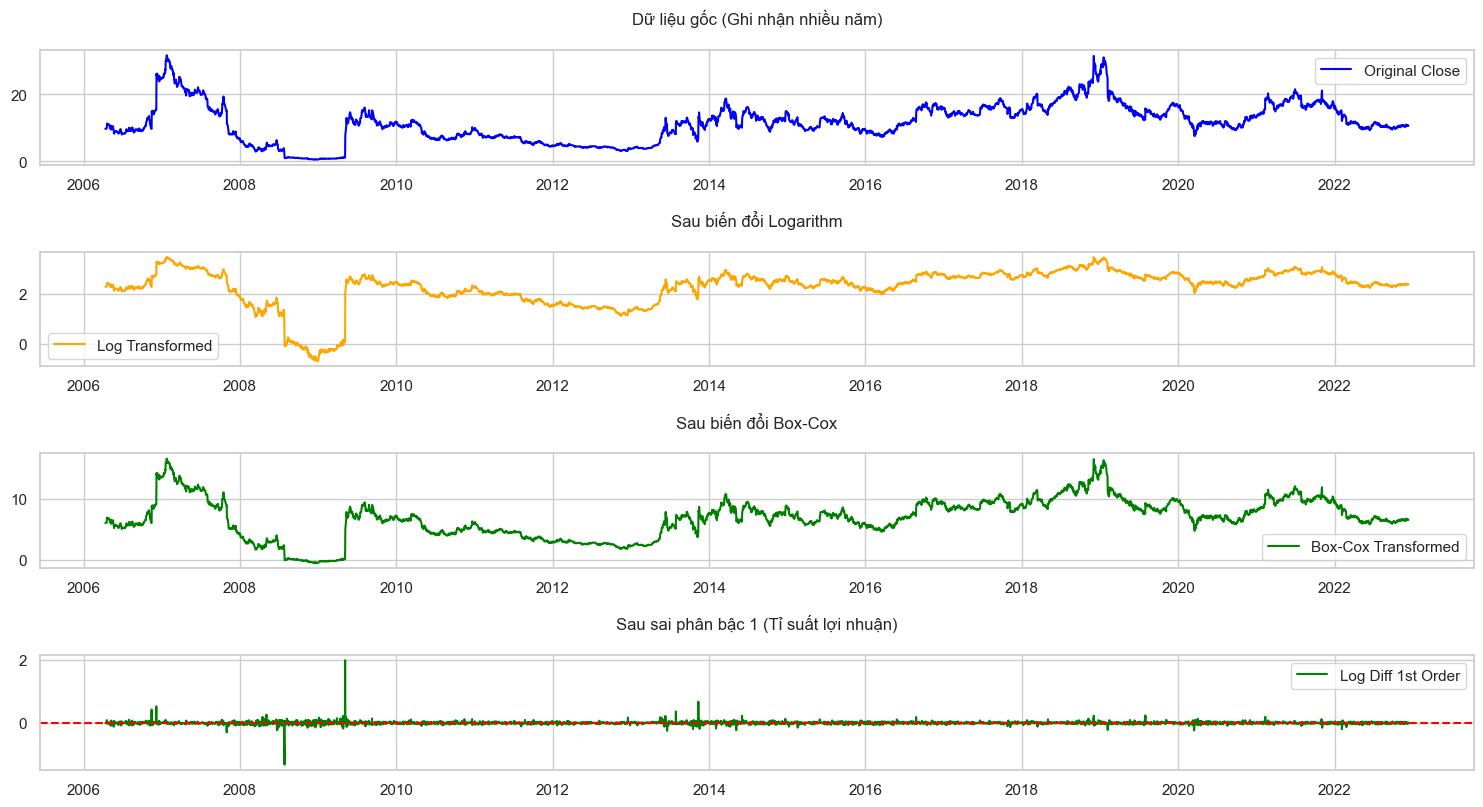

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox

import warnings
warnings.filterwarnings("ignore")


#đọc dữ liệu 
df = pd.read_csv('../data/raw/VNDA.csv')
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date').set_index('Date')

sns.set(style="whitegrid")
series = df['Close'].dropna()

#hàm kiểm định
def check_stationarity(data, label):
    print(f"\n--- {label} ---")
    
    # 1. Kiểm định ADF
    adf_result = adfuller(data)
    # Quy tắc ADF: p-value < 0.05 là DỪNG
    adf_status = 'Dừng' if adf_result[1] < 0.05 else 'Không dừng'
    print(f"ADF p-value: {adf_result[1]:.4f} -> {adf_status}")

    # 2. Kiểm định KPSS
    kpss_res = kpss(data, regression='c', nlags="auto")
    # Quy tắc KPSS: p-value > 0.05 là DỪNG (Ngược với ADF)
    kpss_status = 'Dừng' if kpss_res[1] > 0.05 else 'Không dừng'
    print(f"KPSS p-value: {kpss_res[1]:.4f} -> {kpss_status}")
    
check_stationarity(series, "1. CHUỖI GỐC")

# Logarithm (Ổn định phương sai)
df['Log_Close'] = np.log(series)
check_stationarity(df['Log_Close'], "2. BIẾN ĐỔI LOGARITHM")

#  Box-Cox 
df['BoxCox_Close'], lmbda = boxcox(series)
print(f"Lambda Box-Cox: {lmbda:.4f}")
check_stationarity(df['BoxCox_Close'], "3. BIẾN ĐỔI BOX-COX")

# Phân sai bậc 1
df['Log_Diff1'] = df['Log_Close'].diff()
check_stationarity(df['Log_Diff1'].dropna(), "4. SAI PHÂN BẬC 1 (LOG_DIFF)")




#Vẽ biểu đồ trực quan
plt.figure(figsize=(15, 12))

#đồ thị gốc
plt.subplot(6, 1, 1)
plt.plot(series, label='Original Close', color='blue')
plt.title('Dữ liệu gốc (Ghi nhận nhiều năm)\n')
plt.legend()

# Đồ thị sau Log
plt.subplot(6, 1, 2)
plt.plot(df['Log_Close'], label='Log Transformed', color='orange')
plt.title('Sau biến đổi Logarithm\n')
plt.legend()

# Đồ thị sau Box-Cox
plt.subplot(6, 1, 3)
plt.plot(df['BoxCox_Close'], label='Box-Cox Transformed', color='green')
plt.title('Sau biến đổi Box-Cox\n')
plt.legend()

# Đồ thị sau Sai phân bậc 1
plt.subplot(6, 1, 4)
plt.plot(df['Log_Diff1'], label='Log Diff 1st Order', color='green')
plt.axhline(0, color='red', linestyle='--')
plt.title('Sau sai phân bậc 1 (Tỉ suất lợi nhuận)\n')
plt.legend()



plt.tight_layout()
plt.show()



## c. Phân rã chuỗi thời gian

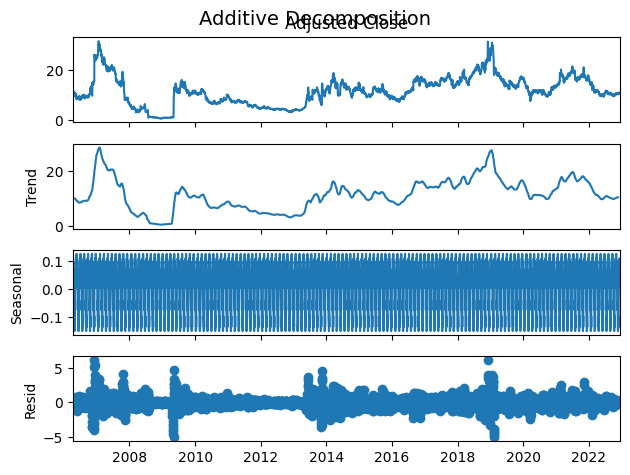

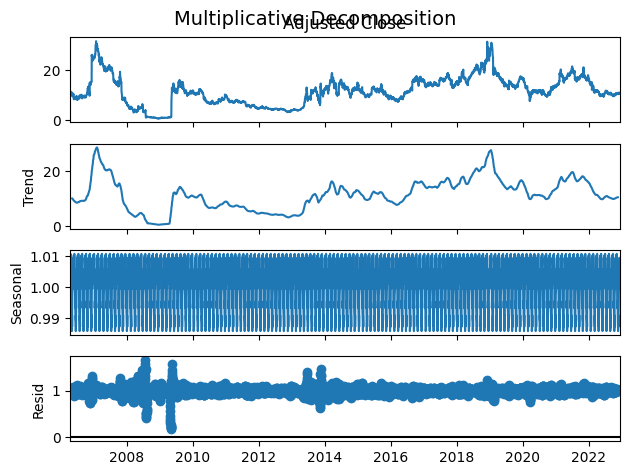

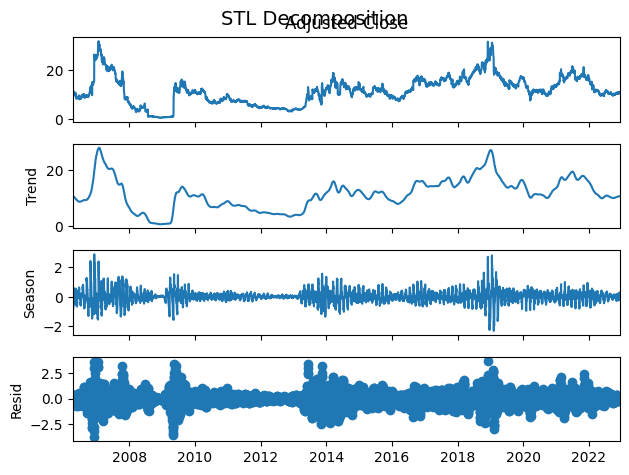

Residual variance: 0.4673149267179811
Original variance: 31.973869312547567
Residual variance ratio: 0.014615526264586056

Sample deseasonalized:
Date
2006-04-12    10.389262
2006-04-13    10.549534
2006-04-17    10.540738
2006-04-18    10.436547
2006-04-19    10.623004
dtype: float64

Sample detrended:
Date
2006-04-12   -1.213965
2006-04-13   -1.143855
2006-04-17   -1.053516
2006-04-18   -0.992954
2006-04-19   -0.392179
dtype: float64


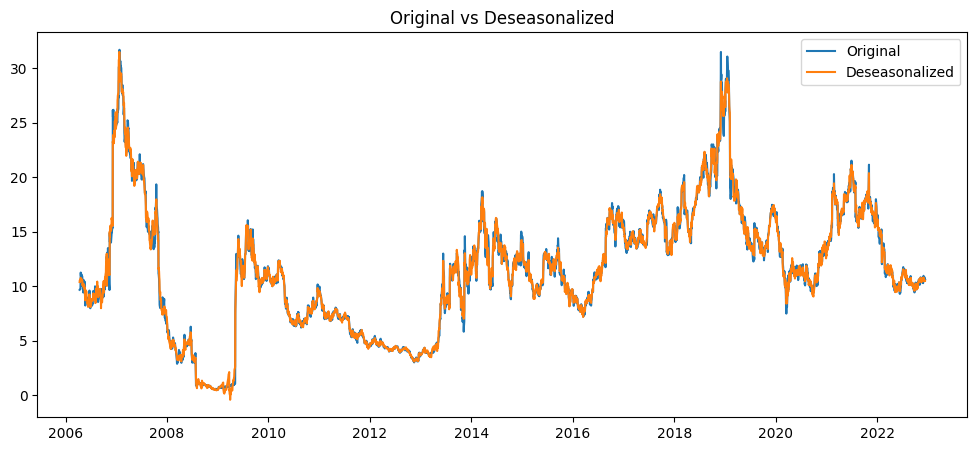

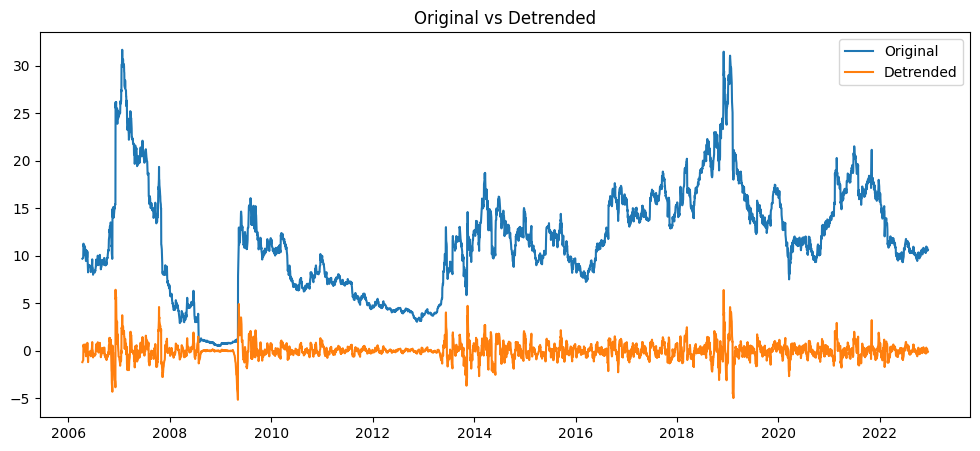

In [7]:
# =========================================
# 2.4.3.c Time Series Decomposition
# =========================================

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL

# =========================
# 1. Chọn chu kỳ mùa vụ
# =========================
# Dữ liệu theo ngày:
period = 30   # tháng

# =========================
# 2. Additive Decomposition
# =========================
additive = seasonal_decompose(series, model='additive', period=period)

additive.plot()
plt.suptitle("Additive Decomposition", fontsize=14)
plt.show()

# =========================
# 3. Multiplicative Decomposition
# =========================
multiplicative = seasonal_decompose(series, model='multiplicative', period=period)

multiplicative.plot()
plt.suptitle("Multiplicative Decomposition", fontsize=14)
plt.show()

# =========================
# 4. STL Decomposition
# =========================
stl = STL(series, period=period)
result = stl.fit()

result.plot()
plt.suptitle("STL Decomposition", fontsize=14)
plt.show()

# =========================
# 5. Residual Variance Ratio
# =========================
residual_var = np.var(result.resid)
original_var = np.var(series)

ratio = residual_var / original_var

print("Residual variance:", residual_var)
print("Original variance:", original_var)
print("Residual variance ratio:", ratio)

# =========================
# 6. Tạo dữ liệu mới
# =========================

# bỏ mùa vụ
deseasonalized = series - result.seasonal

# bỏ trend
detrended = series - result.trend

# xem thử
print("\nSample deseasonalized:")
print(deseasonalized.head())

print("\nSample detrended:")
print(detrended.head())

# =========================
# 7. Vẽ so sánh
# =========================
plt.figure(figsize=(12,5))
plt.plot(series, label='Original')
plt.plot(deseasonalized, label='Deseasonalized')
plt.legend()
plt.title("Original vs Deseasonalized")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(series, label='Original')
plt.plot(detrended, label='Detrended')
plt.legend()
plt.title("Original vs Detrended")
plt.show()

### Nhận xét:

- Phân rã Additive giả định rằng thành phần mùa vụ có biên độ không đổi theo thời gian, trong khi Multiplicative phù hợp khi biên độ thay đổi theo mức giá trị của chuỗi

- STL decomposition cho kết quả linh hoạt và ổn định hơn so với hai phương pháp trên, đặc biệt phù hợp với dữ liệu tài chính

- Giá trị residual variance = 0.4673 nhỏ hơn rất nhiều so với original variance = 31.9739  
-> Residual variance ratio = 0.0146 (~1.46%)

-> Điều này cho thấy phần dư chỉ chiếm một tỷ lệ rất nhỏ so với tổng biến động của chuỗi  
-> Chứng tỏ việc phân rã đã loại bỏ hiệu quả các thành phần xu hướng (trend) và mùa vụ (seasonality)

- Chuỗi deseasonalized đã loại bỏ yếu tố mùa vụ, giúp làm rõ xu hướng chính của dữ liệu
- Chuỗi detrended đã loại bỏ xu hướng dài hạn, giúp phân tích các biến động ngắn hạn và bất thường

-> Các chuỗi này là nền tảng quan trọng cho các bước tiếp theo như phát hiện dị thường (anomaly detection) và xây dựng mô hình dự báo

## d. Trích xuất đặc trưng thời gian<br>

In [35]:
import pandas as pd
import numpy as np
import holidays
from scipy.stats import skew

# 1. Chuẩn bị dữ liệu (Đảm bảo Date là Index)
# df = pd.read_csv('../data/raw/VNDA.csv')
# df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
# df = df.sort_values('Date').set_index('Date')

# ---------------------------------------------------------
# (i) ĐẶC TRƯNG CHU KỲ (Sin/Cos Encoding)
# ---------------------------------------------------------
# Ngày trong tuần: Monday=0, Sunday=6 (Chu kỳ T=7)
day_of_week = df.index.dayofweek
df['day_sin'] = np.sin(2 * np.pi * day_of_week / 7)
df['day_cos'] = np.cos(2 * np.pi * day_of_week / 7)

# Tháng trong năm: Jan=1, Dec=12 (Chu kỳ T=12)
month = df.index.month
df['month_sin'] = np.sin(2 * np.pi * (month - 1) / 12)
df['month_cos'] = np.cos(2 * np.pi * (month - 1) / 12)

# ---------------------------------------------------------
# (ii) NGÀY LỄ (Vietnam Holidays)
# ---------------------------------------------------------
vn_holidays = holidays.VN()
df['is_holiday'] = df.index.map(lambda x: 1 if x in vn_holidays else 0).astype(int)

# ---------------------------------------------------------
# (iii) ĐẶC TRƯNG THỐNG KÊ CỬA SỔ TRƯỢT (Rolling Features)
# ---------------------------------------------------------
# Chúng ta sẽ tính trên cột 'Close' với các tỷ lệ cửa sổ khác nhau
windows = [7, 30, 90]

for w in windows:
    rolling_group = df['Close'].rolling(window=w)
    
    df[f'roll_{w}_mean'] = rolling_group.mean()
    df[f'roll_{w}_std']  = rolling_group.std()
    df[f'roll_{w}_min']  = rolling_group.min()
    df[f'roll_{w}_max']  = rolling_group.max()
    
    # Tính Skewness (Độ lệch của phân phối giá)
    # Lưu ý: cần tối nhất 3 giá trị để tính skew, ở đây ta dùng window w
    df[f'roll_{w}_skew'] = rolling_group.apply(lambda x: skew(x) if len(x) >= w else np.nan)

# Kiểm tra kết quả
print("Các đặc trưng thời gian và thống kê đã trích xuất:")
print(df[['day_sin', 'day_cos', 'is_holiday', 'roll_7_mean', 'roll_7_skew']].tail())

Các đặc trưng thời gian và thống kê đã trích xuất:
             day_sin   day_cos  is_holiday  roll_7_mean  roll_7_skew
Date                                                                
2022-12-06  0.781831  0.623490           0    10.710000    -0.590304
2022-12-07  0.974928 -0.222521           0    10.788571    -0.798101
2022-12-08  0.433884 -0.900969           0    10.837143    -1.094756
2022-12-09 -0.433884 -0.900969           0    10.780000    -0.685822
2022-12-12  0.000000  1.000000           0    10.730000    -0.293362


## e. Phát hiện dị thường (bất thường) trong chuỗi thời gian: 

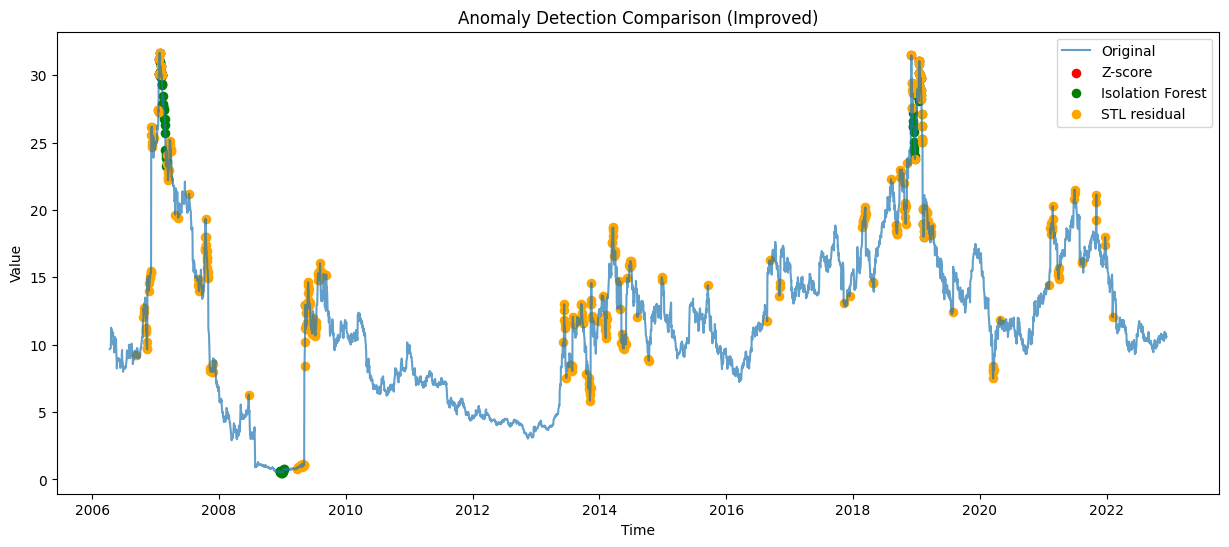

Z-score anomalies: 25
Isolation Forest anomalies: 84
STL anomalies: 342
Z ∩ STL: 19
Z ∩ IF: 20
IF ∩ STL: 34
Robust anomalies (IF ∩ STL): 34


In [18]:
# =========================================
# 2.4.3.e Anomaly Detection (Improved)
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# =========================
# 1. Z-score (Deseasonalized)
# =========================
deseasonalized_clean = deseasonalized.dropna()

z = np.abs(zscore(deseasonalized_clean))
threshold_z = 3

anomaly_z_index = deseasonalized_clean.index[z > threshold_z]

# =========================
# 2. Isolation Forest (TRUE Sliding Window)
# =========================

window_size = 10
X = []

for i in range(len(series) - window_size):
    X.append(series.iloc[i:i+window_size].values)

X = np.array(X)

# scale dữ liệu → rất quan trọng
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = IsolationForest(contamination=0.02, random_state=42)
pred = model.fit_predict(X_scaled)

# map index về điểm cuối window
iso_index = series.index[window_size:]
anomaly_if_index = iso_index[pred == -1]

# =========================
# 3. STL Residual Threshold (robust)
# =========================

residual = result.resid.dropna()

# dùng IQR → robust hơn std
Q1 = residual.quantile(0.25)
Q3 = residual.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

anomaly_stl_index = residual[(residual < lower_bound) | (residual > upper_bound)].index

# =========================
# 4. Plot (clear hơn)
# =========================

plt.figure(figsize=(15,6))
plt.plot(series, label='Original', alpha=0.7)

plt.scatter(anomaly_z_index,
            series.loc[anomaly_z_index],
            color='red', label='Z-score', s=35)

plt.scatter(anomaly_if_index,
            series.loc[anomaly_if_index],
            color='green', label='Isolation Forest', s=35)

plt.scatter(anomaly_stl_index,
            series.loc[anomaly_stl_index],
            color='orange', label='STL residual', s=35)

plt.legend()
plt.title("Anomaly Detection Comparison (Improved)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

# =========================
# 5. Thống kê
# =========================

print("Z-score anomalies:", len(anomaly_z_index))
print("Isolation Forest anomalies:", len(anomaly_if_index))
print("STL anomalies:", len(anomaly_stl_index))

# =========================
# 6. Overlap
# =========================

set_z = set(anomaly_z_index)
set_if = set(anomaly_if_index)
set_stl = set(anomaly_stl_index)

print("Z ∩ STL:", len(set_z & set_stl))
print("Z ∩ IF:", len(set_z & set_if))
print("IF ∩ STL:", len(set_if & set_stl))

# =========================
# 7. Robust anomalies
# =========================

robust_anomalies = set_if & set_stl

print("Robust anomalies (IF ∩ STL):", len(robust_anomalies))

### Nhận xét:

* Số lượng điểm dị thường giữa các phương pháp có sự khác biệt rõ rệt:

  * Z-score phát hiện **25 điểm** → phương pháp bảo thủ, chỉ phát hiện các giá trị lệch rất lớn
  * Isolation Forest phát hiện **84 điểm** → nhạy hơn, phát hiện nhiều mẫu bất thường hơn
  * STL residual phát hiện **342 điểm** → rất nhạy, dễ bắt cả nhiễu lẫn biến động nhỏ

* So sánh giao nhau (overlap):

  * Z ∩ STL = **19** → các bất thường mạnh, rõ rệt
  * Z ∩ IF = **20** → Isolation Forest bao phủ gần hết anomaly của Z-score
  * IF ∩ STL = **34** → mức đồng thuận cao nhất giữa hai phương pháp

→ Điều này cho thấy:

* Z-score chỉ phát hiện **outlier cực đoan**

* Isolation Forest phát hiện **pattern bất thường phức tạp hơn**

* STL residual phát hiện **rất nhiều điểm**, bao gồm cả nhiễu sau khi tách trend/seasonality

* Robust anomalies (IF ∩ STL = 34):
  → Đây là các điểm **đáng tin cậy nhất**, vì được xác nhận bởi 2 phương pháp khác nhau

* Đối với dữ liệu tài chính:

  * Biến động mạnh có thể do tin tức, sự kiện kinh tế hoặc tâm lý thị trường
  * Một số anomaly có thể là nhiễu hoặc biến động ngắn hạn

→ Kết luận:

* **STL residual**: phù hợp cho chuỗi thời gian nhưng cần chọn threshold hợp lý (tránh quá nhạy)
* **Isolation Forest**: tốt để phát hiện bất thường phức tạp
* **Z-score**: đơn giản, dễ hiểu nhưng dễ bỏ sót anomaly

### Lưu ý:

* Nên kết hợp nhiều phương pháp thay vì dùng riêng lẻ
* Các điểm giao nhau (overlap) thường có ý nghĩa thực tế cao hơn


## f. Xây dựng ma trận đặc trưng cho dự báo:

<Figure size 1200x500 with 0 Axes>

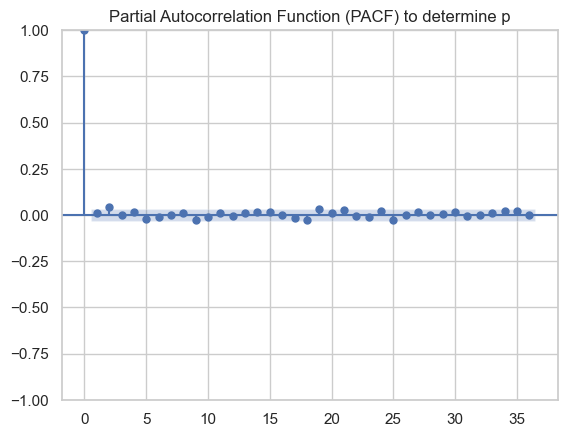

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt



# Vẽ PACF để xác định p
plt.figure(figsize=(12, 5))
plot_pacf(df['Log_Diff1'].dropna(), lags=36, method='ywm')
plt.title('Partial Autocorrelation Function (PACF) to determine p')
plt.show()
# qua biểu đồ, các cột vượt ngưỡng ý nghĩa đến bậc 2, ta chọn p=2
p = 2

### Xây dựng ma trận đặc trưng.

In [41]:
from statsmodels.tsa.seasonal import seasonal_decompose

# (i) Lag Features: t-1, t-2, ..., t-p
for i in range(1, p + 1):
    df[f'lag_{i}'] = df['Log_Diff1'].shift(i)

# (ii) Rolling Statistics (Đã tính ở các bước trước: Mean, Std, Min, Max, Skew cho 7, 30, 90)
# Giả sử các cột đã có tên: roll_7_mean, roll_7_std, roll_30_mean, v.v.

# (iii) Đặc trưng thời gian (Đã tính: day_sin, day_cos, month_sin, month_cos, is_holiday)

# (iv) Chuỗi đã phân rã (Seasonal Decomposition)
# Lưu ý: period=30 (chu kỳ tháng) hoặc 5 (chu kỳ tuần)
# Dùng interpolate để xử lý NaN tạm thời trước khi phân rã
decomp = seasonal_decompose(df['Log_Close'].interpolate(), model='additive', period=30)
df['trend'] = decomp.trend
df['seasonal'] = decomp.seasonal
df['resid'] = decomp.resid

# XÁC ĐỊNH MỤC TIÊU (TARGET): Dự báo giá trị ngày mai (t+1)
df['target'] = df['Log_Diff1'].shift(-1)

# Làm sạch: Loại bỏ các dòng NaN do shift và rolling tạo ra
df_model = df.dropna()

### Huấn luyện mô hình sử dụng 80% dữ liệu để huấn luyện và 20% dữ liệu để kiểm định.

In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Chọn các cột đặc trưng (Loại bỏ các cột gốc và target)
# Cẩn thận: Không đưa giá 'Close' gốc vào X để tránh "Data Leakage" (rò rỉ dữ liệu)
X_cols = [col for col in df_model.columns if col not in 
          ['Low', 'Open', 'Volume', 'High', 'Close', 'Adjusted Close', 'target', 
           'Log_Close', 'Log_Diff1', 'Log_Diff2', 'BoxCox_Close']]

# 2. Chia tập dữ liệu (80% Train, 20% Test)
split = int(len(df_model) * 0.8)
train, test = df_model.iloc[:split], df_model.iloc[split:]

X_train, y_train = train[X_cols], train['target']
X_test, y_test = test[X_cols], test['target']

# 3. Huấn luyện mô hình
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# 4. Dự báo trên tập Test
y_pred = rf.predict(X_test)

# kết quả dự báo
# Tính toán sai số
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- KẾT QUẢ ĐÁNH GIÁ ĐỊNH LƯỢNG ---")
print(f"MAE  (Sai số tuyệt đối trung bình): {mae:.6f}")
print(f"RMSE (Sai số căn bậc hai trung bình): {rmse:.6f}")

results_df = pd.DataFrame({
    'Thực tế (Actual)': y_test.values,
    'Dự đoán (Predicted)': y_pred,
    'Sai số (Error)': y_test.values - y_pred
}, index=y_test.index)

# In ra 10 dòng đầu tiên của kết quả dự báo
print("\n--- BẢNG SO SÁNH KẾT QUẢ DỰ BÁO (10 dòng đầu) ---")
print(results_df.head(10))

--- KẾT QUẢ ĐÁNH GIÁ ĐỊNH LƯỢNG ---
MAE  (Sai số tuyệt đối trung bình): 0.021035
RMSE (Sai số căn bậc hai trung bình): 0.030453

--- BẢNG SO SÁNH KẾT QUẢ DỰ BÁO (10 dòng đầu) ---
            Thực tế (Actual)  Dự đoán (Predicted)  Sai số (Error)
Date                                                             
2019-08-01         -0.030871            -0.015183       -0.015687
2019-08-02          0.001305             0.013849       -0.012544
2019-08-05          0.011673            -0.015777        0.027450
2019-08-06         -0.010369             0.010580       -0.020949
2019-08-07         -0.023065            -0.009266       -0.013799
2019-08-08         -0.020883             0.008226       -0.029109
2019-08-09          0.023546            -0.017825        0.041371
2019-08-12          0.000665            -0.019743        0.020407
2019-08-13         -0.016751            -0.023052        0.006302
2019-08-14          0.007405            -0.017564        0.024969


### g. **[Nâng cao]** Phân tích nhân quả Granger (Granger Causality)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1055.8446, p=0.0000  , df_denom=4192, df_num=1
ssr based chi2 test:   chi2=1056.6002, p=0.0000  , df=1
likelihood ratio test: chi2=942.3627, p=0.0000  , df=1
parameter F test:         F=1055.8446, p=0.0000  , df_denom=4192, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=682.5460, p=0.0000  , df_denom=4189, df_num=2
ssr based chi2 test:   chi2=1366.7214, p=0.0000  , df=2
likelihood ratio test: chi2=1183.0138, p=0.0000  , df=2
parameter F test:         F=682.5460, p=0.0000  , df_denom=4189, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=534.9640, p=0.0000  , df_denom=4186, df_num=3
ssr based chi2 test:   chi2=1607.5757, p=0.0000  , df=3
likelihood ratio test: chi2=1360.7992, p=0.0000  , df=3
parameter F test:         F=534.9640, p=0.0000  , df_denom=4186, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=418.655

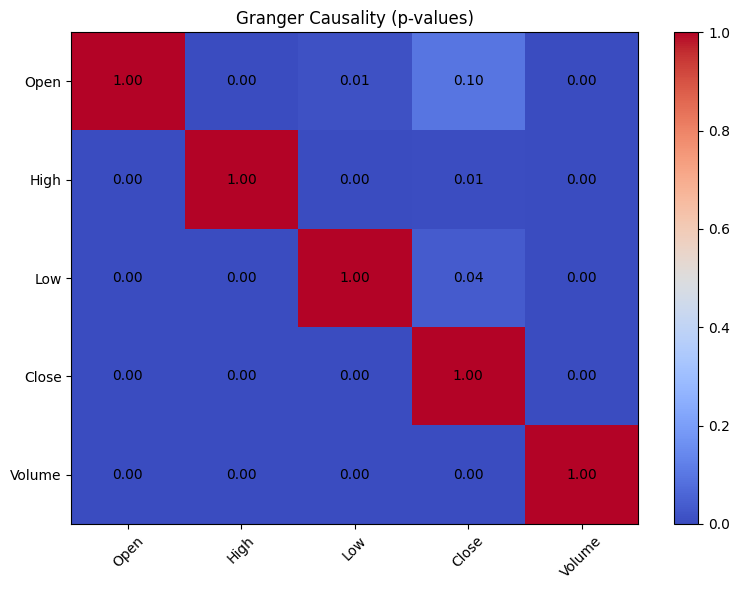

Strong Granger Causality (p < 0.05):
Open → High (p=0.0000)
Open → Low (p=0.0149)
Open → Volume (p=0.0000)
High → Open (p=0.0000)
High → Low (p=0.0000)
High → Close (p=0.0065)
High → Volume (p=0.0000)
Low → Open (p=0.0000)
Low → High (p=0.0000)
Low → Volume (p=0.0000)
Close → Open (p=0.0000)
Close → High (p=0.0000)
Close → Low (p=0.0000)
Close → Volume (p=0.0002)
Volume → Open (p=0.0001)
Volume → High (p=0.0000)
Volume → Low (p=0.0000)
Volume → Close (p=0.0039)


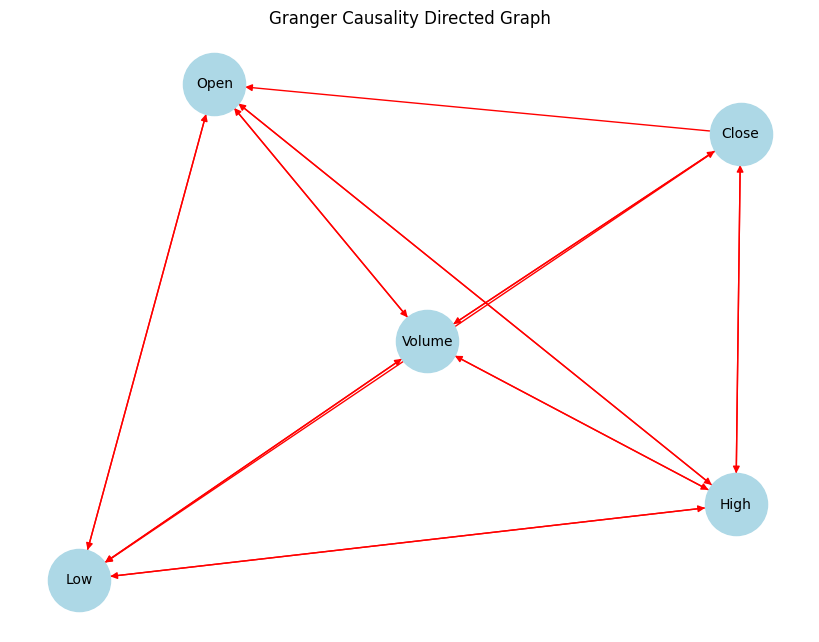

In [17]:
# =========================================
# 2.4.3.g Granger Causality (Final Version)
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import grangercausalitytests
import networkx as nx

# =========================
# 1. Chọn biến
# =========================
cols = ['Open', 'High', 'Low', 'Close', 'Volume']
data = df[cols].dropna()

# =========================
# 2. Làm dừng dữ liệu (stationarity)
# =========================
data_diff = data.diff().dropna()

# =========================
# 3. Tính Granger causality
# =========================
max_lag = 5
variables = data_diff.columns

results_matrix = pd.DataFrame(
    np.ones((len(variables), len(variables))),
    columns=variables,
    index=variables
)

for y in variables:
    for x in variables:
        if x != y:
            test_result = grangercausalitytests(data_diff[[y, x]], max_lag)
            
            p_values = [test_result[i+1][0]['ssr_ftest'][1] for i in range(max_lag)]
            results_matrix.loc[x, y] = np.min(p_values)

# =========================
# 4. Vẽ heatmap bằng matplotlib
# =========================
plt.figure(figsize=(8,6))

plt.imshow(results_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()

plt.xticks(range(len(variables)), variables, rotation=45)
plt.yticks(range(len(variables)), variables)

for i in range(len(variables)):
    for j in range(len(variables)):
        plt.text(j, i, f"{results_matrix.iloc[i, j]:.2f}",
                 ha='center', va='center')

plt.title("Granger Causality (p-values)")
plt.tight_layout()
plt.show()

# =========================
# 5. In quan hệ mạnh
# =========================
print("Strong Granger Causality (p < 0.05):")

edges = []
threshold = 0.02

for x in variables:
    for y in variables:
        if x != y and results_matrix.loc[x, y] < threshold:
            print(f"{x} → {y} (p={results_matrix.loc[x, y]:.4f})")
            edges.append((x, y))

# =========================
# 6. Vẽ directed graph
# =========================
G = nx.DiGraph()
G.add_edges_from(edges)

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)

nx.draw(G, pos,
        with_labels=True,
        node_size=2000,
        node_color='lightblue',
        font_size=10,
        edge_color='red',
        arrows=True)

plt.title("Granger Causality Directed Graph")
plt.show()

### Nhận xét:

- Kết quả Granger causality cho thấy hầu hết các biến đều có quan hệ dự báo lẫn nhau (p-value < 0.05)

- Đặc biệt, tồn tại nhiều quan hệ hai chiều (bidirectional), ví dụ:
  + Open ↔ High
  + High ↔ Low
  + Close ↔ Volume

→ Điều này cho thấy các biến có mối liên hệ rất chặt chẽ

- Nguyên nhân:
  + Các biến Open, High, Low, Close đều được tạo ra từ cùng một chuỗi giá
  + Do đó chúng có tương quan cao và dễ tạo ra quan hệ Granger-cause giả

- Volume cũng có ảnh hưởng đến các biến giá và ngược lại, phản ánh hoạt động giao dịch trên thị trường

→ Tuy nhiên:
- Việc có quá nhiều quan hệ Granger-cause có thể do hiện tượng đa cộng tuyến (multicollinearity)
- Điều này làm giảm ý nghĩa thực tế của kiểm định

→ Kết luận:
- Granger causality cho thấy các biến có khả năng dự báo lẫn nhau
- Tuy nhiên cần thận trọng khi diễn giải vì các biến không độc lập

Lưu ý:
- Granger causality chỉ phản ánh quan hệ dự báo, không phải quan hệ nhân quả thực sự